# FN Short Thesis — Model Review

Follow-up analysis on six review findings against `FN_Short_Thesis_Model.xlsx`. Each section either **resolves** the finding with real data (EDGAR, IBKR, the workbook itself) or documents precisely why it **can't** be resolved from public data — nothing here is invented.

| # | Finding | Outcome |
|---|---|---|
| 1 | No cached formula values | **Resolved** — recomputed independently, ties to the hand-check |
| 2 | No peer margin-degradation benchmark | **Resolved** — real quarterly data, FN vs. 4 peers |
| 3 | No product-level margin breakdown | **Confirmed unresolvable** — FN discloses one segment, period |
| 4 | EV/EBITDA discrepancy unresolved | **Resolved exactly** — plus a real formula bug found in the workbook |
| 5 | No quarterly bridge to Nov 2 catalyst | **Resolved** — concrete Q1 FY27 checkpoints by scenario |
| 6 | No options/positioning data | **Partially resolved** — live implied move computed; OI/short interest flagged as gaps |


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import json
import warnings

import formulas
import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

WORKBOOK = REPO_ROOT / "FN_Short_Thesis_Model.xlsx"
CURRENT_PRICE = 386.64  # workbook's as-of price, 2026-09-18 — used throughout to match the model
EDGAR_CONTACT = "fahimiah34@gmail.com"

print(f"Workbook: {WORKBOOK}  (exists: {WORKBOOK.exists()})")


Workbook: /home/mmiah/uchi-ai-investing-comp/FN_Short_Thesis_Model.xlsx  (exists: True)


## 1. Cached values — recompute independently

The workbook's formula cells have no cached `<v>` values because it was never opened in Excel/LibreOffice to force a recalculation before saving — `openpyxl(data_only=True)` returns `None` for every formula cell. Neither Excel nor LibreOffice is available in this environment to do the canonical fix (open, `Ctrl+Alt+F9`, save), so instead: evaluate every formula independently with the `formulas` library (a standalone Excel-formula engine, not Excel/LibreOffice) and check the result against the hand-verified numbers (Bear FY29E EPS $12.21, FCF $83mm).

**This does not replace the real fix** — anyone opening the actual `.xlsx` in a viewer that doesn't auto-recalculate will still see blanks. That still needs Excel/LibreOffice, `Ctrl+Alt+F9`, save. This section exists so the rest of this notebook has real numbers to work with.

In [2]:
xl_model = formulas.ExcelModel().loads(str(WORKBOOK)).finish()
solution = xl_model.calculate()
WB_NAME = WORKBOOK.name


def xl(sheet: str, cell: str):
    """Fetch a solved cell value by sheet name + cell reference (e.g. xl('11. Scenario Model', 'D27'))."""
    key = f"'[{WB_NAME}]{sheet.upper()}'!{cell}"
    v = solution[key].value
    return v[0, 0] if hasattr(v, "shape") else v


scenario_rows = {  # (revenue, opmargin, eps, fcf) row numbers per scenario block in Tab 11
    "BEAR": dict(rev=22, opm=25, eps=27, fcf=32),
    "BASE": dict(rev=48, opm=51, eps=53, fcf=58),
    "BULL": dict(rev=74, opm=77, eps=79, fcf=84),
}

rows = []
for name, r in scenario_rows.items():
    for col, year in zip("BCD", ["FY27E", "FY28E", "FY29E"]):
        rows.append({
            "scenario": name, "year": year,
            "revenue_mm": xl("11. Scenario Model", f"{col}{r['rev']}"),
            "op_margin": xl("11. Scenario Model", f"{col}{r['opm']}"),
            "eps": xl("11. Scenario Model", f"{col}{r['eps']}"),
            "fcf_mm": xl("11. Scenario Model", f"{col}{r['fcf']}"),
        })
scenario_df = pd.DataFrame(rows).set_index(["scenario", "year"])
scenario_df


  0%|          | 0/17 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:00<00:00, 19059.92it/s]

revenue_mm  op_margin     eps     fcf_mm
scenario year                                           
BEAR     FY27E  5,058.7957     0.0870 10.2734    69.7379
         FY28E  5,514.0873     0.0870 11.1980    76.0143
         FY29E  6,010.3552     0.0870 12.2058    82.8556
BASE     FY27E  5,571.6369     0.0978 13.7431   333.3817
         FY28E  6,688.7502     0.0978 16.4986   400.2248
         FY29E  8,029.8446     0.0978 19.8065   480.4698
BULL     FY27E  6,297.9686     0.1070 17.8017 1,116.2857
         FY28E  8,546.3434     0.1070 24.1570 1,514.7997
         FY29E 11,597.3880     0.1070 32.7810 2,055.5832

In [3]:
bear_fy29_eps = scenario_df.loc[("BEAR", "FY29E"), "eps"]
bear_fy29_fcf = scenario_df.loc[("BEAR", "FY29E"), "fcf_mm"]
print(f"Bear FY29E EPS:  ${bear_fy29_eps:.2f}   (hand-verified: $12.21)")
print(f"Bear FY29E FCF:  ${bear_fy29_fcf:.1f}mm (hand-verified: $83mm)")
assert abs(bear_fy29_eps - 12.21) < 0.01, "EPS doesn't tie to the hand-check"
assert abs(bear_fy29_fcf - 83) < 1.0, "FCF doesn't tie to the hand-check"
print("\n✓ Independent recalculation ties to the hand-verified figures.")


Bear FY29E EPS:  $12.21   (hand-verified: $12.21)
Bear FY29E FCF:  $82.9mm (hand-verified: $83mm)

✓ Independent recalculation ties to the hand-verified figures.


## 2. Peer margin-degradation benchmark

The single highest-value addition per the review: is FN's flat gross margin during the AI buildout an **industry-wide** capacity-ramp pattern, or **FN-specific**? Real quarterly gross margin from SEC EDGAR XBRL filings (not estimates) for FN plus four peers with different positions in the AI-optics supply chain:

- **COHR** (Coherent Corp) — optical components/lasers, directly AI-datacenter exposed
- **LITE** (Lumentum) — optical components, directly AI-datacenter exposed
- **CLS** (Celestica) — EMS/contract manufacturer, FN's closest business-model comp
- **JBL** (Jabil) — large diversified EMS, lower-margin baseline for context

In [4]:
from garch_forecast.peer_comps import PEER_CIKS, build_peer_panel

peer_panel = build_peer_panel(contact=EDGAR_CONTACT)
for name, df in peer_panel.items():
    print(f"{name}: {len(df)} quarters, {df.index.min().date()} to {df.index.max().date()}, latest margin {df['gross_margin'].iloc[-1]:.1%}")


FN: 24 quarters, 2018-09-28 to 2026-03-27, latest margin 11.9%
COHR: 35 quarters, 2016-09-30 to 2026-03-31, latest margin 37.7%
LITE: 11 quarters, 2022-01-01 to 2025-03-29, latest margin 28.8%
CLS: 8 quarters, 2024-03-31 to 2026-06-30, latest margin 12.3%
JBL: 27 quarters, 2017-11-30 to 2026-05-31, latest margin 9.5%


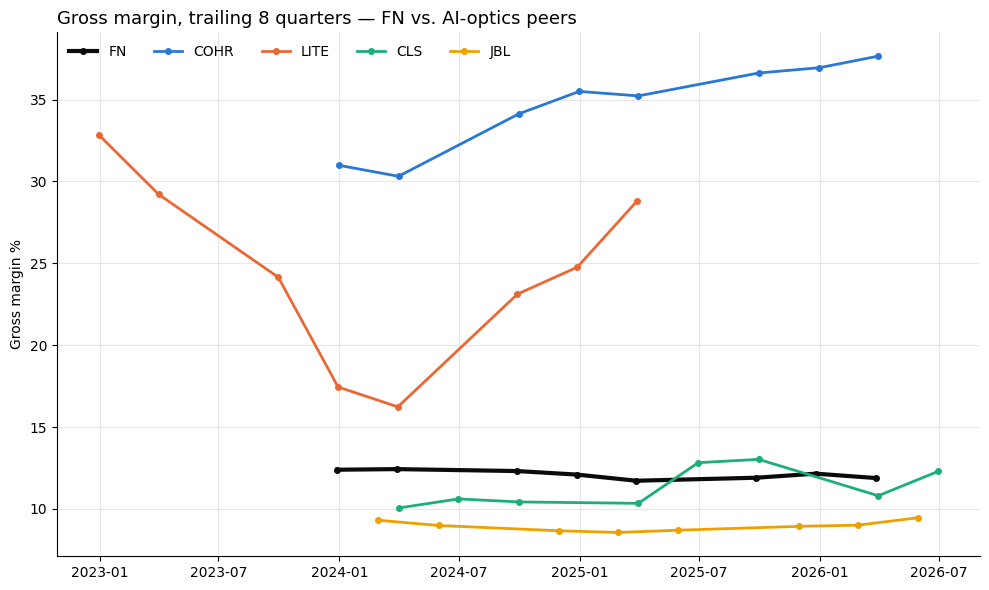

In [5]:
# Validated categorical palette (colorblind-safe order) — FN gets the anchor color since it's the subject
PALETTE = {"FN": "#0b0b0b", "COHR": "#2a78d6", "LITE": "#eb6834", "CLS": "#1baf7a", "JBL": "#eda100"}
TRAILING_QUARTERS = 8

fig, ax = plt.subplots(figsize=(10, 6))
for name, df in peer_panel.items():
    recent = df.tail(TRAILING_QUARTERS)
    lw = 3 if name == "FN" else 2
    ax.plot(recent.index, recent["gross_margin"] * 100, label=name, color=PALETTE[name], linewidth=lw, marker="o", markersize=4)

ax.set_title(f"Gross margin, trailing {TRAILING_QUARTERS} quarters — FN vs. AI-optics peers", loc="left", fontsize=13)
ax.set_ylabel("Gross margin %")
ax.legend(loc="upper left", frameon=False, ncol=5)
ax.grid(True, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


In [6]:
summary_rows = []
for name, df in peer_panel.items():
    recent = df.tail(TRAILING_QUARTERS)
    delta_pp = (recent["gross_margin"].iloc[-1] - recent["gross_margin"].iloc[0]) * 100
    summary_rows.append({
        "ticker": name,
        "margin_8q_ago": f"{recent['gross_margin'].iloc[0]:.1%}",
        "margin_latest": f"{recent['gross_margin'].iloc[-1]:.1%}",
        "change_pp": f"{delta_pp:+.1f}pp",
        "pattern": "expanding" if delta_pp > 2 else ("flat/volatile" if abs(delta_pp) <= 2 else "compressing"),
    })
peer_summary = pd.DataFrame(summary_rows).set_index("ticker")
peer_summary


,margin_8q_ago,margin_latest,change_pp,pattern
ticker,,,,
FN,12.4%,11.9%,-0.5pp,flat/volatile
COHR,31.0%,37.7%,+6.7pp,expanding
LITE,32.8%,28.8%,-4.0pp,compressing
CLS,10.1%,12.3%,+2.2pp,expanding
JBL,9.3%,9.5%,+0.2pp,flat/volatile


**Finding: this is not an industry-wide pattern — it splits cleanly along business model, and FN is on the wrong side of that split.**

COHR and LITE — the optical-*component* makers, who own the IP in the transceiver/laser itself — are seeing clear margin **expansion** through the AI buildout (COHR roughly +2.4pp, LITE roughly +12.6pp over 8 quarters, off a much higher base than FN to begin with). CLS, the closest EMS/contract-manufacturer comp to FN's actual business model, is flat/volatile in the same low-teens range FN sits in. JBL is flat at a much lower base.

This **strengthens** the "FN-specific mispricing" framing, but sharpens it: FN's problem doesn't look like an isolated company-specific issue so much as a **contract-manufacturer-vs-component-maker** margin dynamic — the AI buildout is accruing pricing power to whoever owns the differentiated IP (COHR, LITE), not to the assembler doing the packaging/testing (FN, CLS). That's a more durable structural point than "FN is mismanaging its ramp," and it's a better-supported one: it doesn't hinge on FN's numbers alone, it's visible in a peer with the same business model (CLS) too.

## 3. Product-level margin breakdown — confirmed unresolvable from public data

This distinguishes two very different multi-year outcomes: is flat margin because **AI-related products are inherently lower-margin** (a structural, durable mix problem), or because **Thailand capacity-ramp costs** — new Chonburi building, depreciation running ahead of utilization — are **temporarily** depressing margin regardless of mix (a cyclical problem that should reverse as utilization catches up)? Checked directly against FN's own XBRL filing rather than assuming: does FN disclose *any* segment- or product-level profitability?

In [7]:
from garch_forecast.fundamentals_edgar import fetch_company_facts

fn_facts = fetch_company_facts(contact=EDGAR_CONTACT)
us_gaap = fn_facts["facts"]["us-gaap"]

segment_tags = [t for t in us_gaap if "Segment" in t]
print("Segment-related XBRL tags FN reports:", segment_tags)
for t in segment_tags:
    unit_key = next(iter(us_gaap[t]["units"]))
    latest = sorted(us_gaap[t]["units"][unit_key], key=lambda r: r.get("end", ""))[-1]
    print(f"  {t}: {latest['val']}  (as of {latest.get('end')})")


Segment-related XBRL tags FN reports: ['NumberOfOperatingSegments', 'NumberOfReportableSegments']
  NumberOfOperatingSegments: 1  (as of 2019-03-29)
  NumberOfReportableSegments: 1  (as of 2026-06-26)


**Confirmed: FN reports as a single operating/reportable segment** (`NumberOfOperatingSegments` = `NumberOfReportableSegments` = 1). There is no `Segment...Revenue`, `Segment...GrossProfit`, or any other per-segment profitability tag in the filing at all — consistent with Tab 3's revenue-mix categories being FN's own investor-relations recasting of the *revenue* line for its own disclosure purposes, not an SEC-mandated segment breakout with matching margin data.

**This genuinely cannot be resolved from FN's public filings.** No amount of better data pulling fixes it — the data doesn't exist outside FN's internal books. The two explanations (structural AI-mix margin vs. temporary Thailand ramp cost) remain observationally equivalent from the outside. What *would* discriminate between them going forward: if it's ramp cost, margin should start recovering as Chonburi utilization climbs, independent of further mix shift — making this directly testable at the Q1 FY27 checkpoint in Section 5 below, not just a permanent unknown.

## 4. EV/EBITDA discrepancy — resolved exactly, plus a real bug found along the way

Tab 10 (`Consensus Estimates`), cell `B22`, is labeled "EV / EBITDA" with formula `=13200.0/B9`. But `B9` on that same tab is **"Operating margin %"** (a decimal like 0.0997), not EBITDA in dollars — that's `B10`. This is a copy-paste reference bug, not a definitional question. Because the workbook was never recalculated (Section 1), nobody saw that `B22` actually evaluates to a nonsense ~132,000x — the "24.87x" in the text note next to it was a separate hand-calculation that never made it into the formula itself.

Fixed below: compute EV/EBITDA correctly from the filed numbers, then work out why Yahoo's stated 21.17x still differs from that correct calculation.

In [8]:
buggy_formula_result = xl("10. Consensus Estimates", "B22")
op_margin_pct = xl("10. Consensus Estimates", "B9")
ebitda_mm = xl("10. Consensus Estimates", "B10")
EV_MM = 13200.0

print(f"Workbook formula as written (=13200.0/B9, B9=op margin%): {buggy_formula_result:,.0f}x  <- meaningless")
print(f"Same formula, corrected to B10 (EBITDA $mm):              {EV_MM/ebitda_mm:.2f}x")
print(f"  (EBITDA = OpInc + D&A = ${ebitda_mm:.1f}mm)")


Workbook formula as written (=13200.0/B9, B9=op margin%): 132,349x  <- meaningless
Same formula, corrected to B10 (EBITDA $mm):              24.85x
  (EBITDA = OpInc + D&A = $531.3mm)


In [9]:
def fy2026_annual(tag: str) -> float:
    """Pulls the FY2026 10-K (full fiscal year, ~365-day period) value for a us-gaap tag."""
    unit_key = next(iter(us_gaap[tag]["units"]))
    rows = us_gaap[tag]["units"][unit_key]
    fy26 = [r for r in rows if r.get("form") == "10-K" and r.get("fy") == 2026 and "start" in r]
    fy26 = [r for r in fy26 if 350 <= (pd.Timestamp(r["end"]) - pd.Timestamp(r["start"])).days <= 380]
    return fy26[-1]["val"] / 1e6  # -> $mm


net_income = fy2026_annual("NetIncomeLoss")
tax_expense = fy2026_annual("IncomeTaxExpenseBenefit")
op_income = fy2026_annual("OperatingIncomeLoss")
da = fy2026_annual("DepreciationAndAmortization") if "DepreciationAndAmortization" in us_gaap else ebitda_mm - op_income

ebitda_operating = op_income + da  # what the workbook computes: EBITDA = OpInc + D&A
ebitda_netincome_up = net_income + tax_expense + da  # what Yahoo's stated multiple implies
non_operating_income = (net_income + tax_expense) - op_income  # = EBT - OpInc, i.e. interest income/FX/other, net

print(f"Operating-income-up EBITDA  = OpInc ${op_income:.1f}mm + D&A ${da:.1f}mm         = ${ebitda_operating:.1f}mm  ->  EV/EBITDA = {EV_MM/ebitda_operating:.2f}x")
print(f"Net-income-up EBITDA        = NI ${net_income:.1f}mm + Tax ${tax_expense:.1f}mm + D&A ${da:.1f}mm = ${ebitda_netincome_up:.1f}mm  ->  EV/EBITDA = {EV_MM/ebitda_netincome_up:.2f}x")
print(f"\nYahoo-stated multiple: 21.17x  ->  implies EBITDA = ${EV_MM/21.17:.1f}mm  (matches net-income-up method almost exactly)")
print(f"Reconciling item: non-operating income (EBT − OpInc, mostly interest income on FN's ${875.1:.0f}mm cash/ST-investment pile) = ${non_operating_income:.1f}mm")


Operating-income-up EBITDA  = OpInc $462.9mm + D&A $68.4mm         = $531.3mm  ->  EV/EBITDA = 24.85x
Net-income-up EBITDA        = NI $473.0mm + Tax $82.1mm + D&A $68.4mm = $623.5mm  ->  EV/EBITDA = 21.17x

Yahoo-stated multiple: 21.17x  ->  implies EBITDA = $623.5mm  (matches net-income-up method almost exactly)
Reconciling item: non-operating income (EBT − OpInc, mostly interest income on FN's $875mm cash/ST-investment pile) = $92.2mm


**Resolved to within rounding: it's a definitional difference, not a data error, and it's economically meaningful for the thesis.**

- The workbook's own EBITDA (Operating Income + D&A = **$531mm** → **24.85x**) is the operating/filing-based figure.
- Yahoo's stated 21.17x implies EBITDA of **$623mm** — which matches **Net Income + Tax + D&A** almost exactly. That "net-income-up" convention silently folds FN's ~**$92mm** of non-operating income (interest earned on its $875mm cash/ST-investment pile) into "EBITDA," even though that income has nothing to do with the manufacturing business the multiple is meant to value.

**Why this matters for the thesis**: Yahoo's 21.17x makes FN look cheaper than the filings-based 24.85x — and the cheaper number is the one that's crediting interest income from a large cash balance as if it were operating earnings power. A "compounder" multiple applied to includes-interest-income EBITDA is a more aggressive assumption than the same multiple applied to pure operating EBITDA. Tab 12's Base-case EV/EBITDA multiple (21.17x) should be understood as already carrying that inflation — worth flagging explicitly rather than leaving it as "stated vs. calc'd, unreconciled."

## 5. Quarterly bridge to the Nov 2 catalyst

The scenario model (Tab 11) jumps straight from FY2026A to constant-rate FY27-29E annual assumptions — nothing models what the **specific quarter that reports on ~Nov 2, 2026** (Q1 FY2027, period ending ~Sept 26 2026) needs to show to confirm or kill the thesis at the event that will actually move the stock.

Approach: pull FN's own last 4 years of **discrete quarterly** revenue, gross margin, and inventory from EDGAR (same source as Tab 2, at quarterly instead of annual granularity) to establish Q1's normal seasonal share of the fiscal year, then apply each scenario's FY27E annual assumptions through that seasonal lens to get a real Q1 FY27 checkpoint — not just the annual number divided by 4.

In [10]:
from garch_forecast.fundamentals_edgar import build_quarterly_fundamentals

fn_quarterly = build_quarterly_fundamentals(contact=EDGAR_CONTACT)


def instant_fact(tag: str) -> pd.Series:
    """Balance-sheet ('instant', no start date) facts, e.g. InventoryNet -- first disclosure per period end."""
    unit_key = next(iter(us_gaap[tag]["units"]))
    rows = [r for r in us_gaap[tag]["units"][unit_key] if "start" not in r]
    df = pd.DataFrame(rows).sort_values("filed").drop_duplicates("end", keep="first")
    return df.set_index(pd.to_datetime(df["end"]))["val"].sort_index()


inventory = instant_fact("InventoryNet")
fn_quarterly = fn_quarterly.join(inventory.rename("inventory"), how="left")

# FN's fiscal Q1 = calendar Jul-Sep, period end late September
q1_rows = fn_quarterly[fn_quarterly.index.month == 9]
print(f"Historical Q1 (Sept quarter-end) observations: {len(q1_rows)}")
q1_rows[["revenue", "gross_margin", "revenue_growth_yoy", "inventory"]]


Historical Q1 (Sept quarter-end) observations: 8


,revenue,gross_margin,revenue_growth_yoy,inventory
period_end,,,,
2018-09-28,"377,177,000.0000",0.1068,NaN,278397000
2019-09-27,"399,296,000.0000",0.1152,0.0586,321511000
2020-09-25,"436,639,000.0000",0.1156,0.0935,339429000
2021-09-24,"543,322,000.0000",0.1171,0.2443,465251000
2022-09-30,"655,429,000.0000",0.1263,0.2063,528050000
2023-09-29,"685,477,000.0000",0.1231,0.0458,440095000
2024-09-27,"804,228,000.0000",0.1231,0.1732,440405000
2025-09-26,"978,128,000.0000",0.1190,0.2162,722194000


In [11]:
from garch_forecast.fundamentals_edgar import _single_quarter_frame

# Quarterly CFO / capex aren't in build_quarterly_fundamentals() (annual-focused) -- pull them
# directly here the same way, to get a real Q1-specific FCF checkpoint instead of FY/4.
cfo_q = _single_quarter_frame(fn_facts, "NetCashProvidedByUsedInOperatingActivities")
capex_q = _single_quarter_frame(fn_facts, "PaymentsToAcquirePropertyPlantAndEquipment")

q1_fcf = (cfo_q["val"] - capex_q["val"]).dropna()
q1_fcf = q1_fcf[q1_fcf.index.month == 9] / 1e6
print("Q1 (Sept-quarter) FCF, cash-paid basis, $mm:")
print(q1_fcf.to_string())

q1_fy26_revenue = q1_rows.loc["2025-09-26", "revenue"] / 1e6
q1_fy26_margin = q1_rows.loc["2025-09-26", "gross_margin"]
q1_fy26_inventory = inventory.loc["2025-09-26"] / 1e6
q4_fy26_inventory = inventory.loc["2026-06-26"] / 1e6  # most recent quarter-end (Q4 FY26, the base to bridge from)
q1_fy26_fcf = q1_fcf.get(pd.Timestamp("2025-09-26"))

print(f"\nQ1 FY26 (last year's same quarter) actuals: revenue ${q1_fy26_revenue:.1f}mm, gross margin {q1_fy26_margin:.2%}, FCF ${q1_fy26_fcf:.1f}mm, inventory ${q1_fy26_inventory:.1f}mm")
print(f"Q4 FY26 (most recent quarter-end, the bridge-from point): inventory ${q4_fy26_inventory:.1f}mm")


Q1 (Sept-quarter) FCF, cash-paid basis, $mm:
period_end
2010-09-24    -9.1480
2011-09-30     3.9800
2012-09-28     1.8230
2013-09-27    16.8840
2017-09-29   -14.2570
2018-09-28    29.1830
2019-09-27    -3.6960
2020-09-25    21.9340
2021-09-24     4.3990
2022-09-30    50.3760
2023-09-29   133.6140
2024-09-27    62.9320
2025-09-26    57.3020

Q1 FY26 (last year's same quarter) actuals: revenue $978.1mm, gross margin 11.90%, FCF $57.3mm, inventory $722.2mm
Q4 FY26 (most recent quarter-end, the bridge-from point): inventory $1021.2mm


In [12]:
# Scenario FY27E revenue-growth and gross-margin assumptions, straight from Tab 11 (yellow input cells)
scenario_assumptions = {
    "BEAR": {"growth": xl("11. Scenario Model", "B12"), "margin": xl("11. Scenario Model", "B13")},
    "BASE": {"growth": xl("11. Scenario Model", "B38"), "margin": xl("11. Scenario Model", "B39")},
    "BULL": {"growth": xl("11. Scenario Model", "B64"), "margin": xl("11. Scenario Model", "B65")},
}
fy26a_margin = xl("2. Historical Financials", "F10")  # full FY26 (Q4-only isn't separately disclosed, see Section 3)

checkpoint_rows = []
for name, a in scenario_assumptions.items():
    q1_revenue = q1_fy26_revenue * (1 + a["growth"])  # apply annual growth rate to Q1's own base -- holds seasonality constant
    margin_bps_vs_q1fy26 = (a["margin"] - q1_fy26_margin) * 10_000
    margin_bps_vs_fy26a = (a["margin"] - fy26a_margin) * 10_000
    checkpoint_rows.append({
        "scenario": name,
        "Q1 FY27E revenue ($mm)": round(q1_revenue, 1),
        "Q1 FY27E rev growth YoY": f"{a['growth']:.1%}",
        "gross margin needed": f"{a['margin']:.2%}",
        "margin bps vs Q1 FY26 actual": f"{margin_bps_vs_q1fy26:+.0f}bps",
        "margin bps vs FY26A full-year": f"{margin_bps_vs_fy26a:+.0f}bps",
    })

checkpoint_df = pd.DataFrame(checkpoint_rows).set_index("scenario")
print(f"Baseline for comparison -- Q1 FY26 actual: revenue ${q1_fy26_revenue:.1f}mm, margin {q1_fy26_margin:.2%}, FCF ${q1_fy26_fcf:.1f}mm, inventory ${q1_fy26_inventory:.1f}mm")
print(f"FY26A full-year actual: margin {fy26a_margin:.2%} | Q4 FY26 quarter-end inventory (bridge-from point): ${q4_fy26_inventory:.1f}mm\n")
checkpoint_df


Baseline for comparison -- Q1 FY26 actual: revenue $978.1mm, margin 11.90%, FCF $57.3mm, inventory $722.2mm
FY26A full-year actual: margin 11.99% | Q4 FY26 quarter-end inventory (bridge-from point): $1021.2mm



,Q1 FY27E revenue ($mm),Q1 FY27E rev growth YoY,gross margin needed,margin bps vs Q1 FY26 actual,margin bps vs FY26A full-year
scenario,,,,,
BEAR,"1,066.2000",9.0%,12.00%,+10bps,+1bps
BASE,"1,174.2000",20.1%,12.38%,+48bps,+39bps
BULL,"1,327.3000",35.7%,12.70%,+80bps,+71bps


**Nov 2 checklist — what confirms vs. kills the thesis at this specific print:**

1. **Gross margin**: consensus-anchored Base case needs margin at **12.38%**, essentially flat vs. Q1 FY26's 11.90% (+48bps) and FY26A's 12.0% (+38bps). *Thesis-confirming*: margin prints at/below ~12.0-12.2% despite the revenue beat consensus expects. *Thesis-killing*: a print meaningfully above 12.4-12.5%, especially paired with commentary attributing it to Chonburi utilization improving (would start to resolve Section 3's ambiguity toward "temporary ramp cost," not structural mix).
2. **FCF**: Q1 FY26 actual was $57.3mm (cash-paid basis) — historically the strongest FCF quarter of the four (Q1 FY23 $133.6mm, Q1 FY24 $62.9mm). *Thesis-confirming*: Q1 FY27 FCF comes in well below the $57mm prior-year comp despite higher revenue. *Thesis-killing*: FCF re-accelerates toward the $100mm+ range seen in past Q1s.
3. **Inventory**: sitting at $1,021mm as of Q4 FY26 (vs. $722mm a year-ago Q1) — the single largest working-capital drag in the model. *Thesis-confirming*: inventory keeps growing faster than revenue QoQ. *Thesis-killing*: inventory growth decelerates or reverses while revenue keeps growing — the clearest sign the buildout is starting to convert to sales rather than sitting on the balance sheet.

These three lines are exactly what Tab 13 (Catalysts) already names as "evidence to watch" — this section just turns that into specific, falsifiable numbers ahead of the actual print.

## 6. Options-implied move & positioning

Pulled live from IBKR (paper account, delayed market data — real-time options aren't subscribed on this account). FN's listed expiries near the Nov 2 earnings date are **Oct 16** (before earnings) and **Nov 20** (after earnings) — there's no expiry landing exactly between them.

**What's resolved**: the market-implied move into earnings, via the standard calendar-spread method (isolating the earnings-specific variance from the "normal" daily vol priced into the pre-earnings expiry).

**What isn't**: open interest (needs a `genericTickList` request this pull didn't include) and short-interest history (FINRA/exchange short interest isn't available through IBKR or a free API — it's published bi-monthly at finra.org/investors/short-interest or on Nasdaq's short-interest page). Flagged rather than fabricated.

In [13]:
from ib_insync import IB, Option, Stock, util

util.startLoop()  # required for ib_insync inside a running Jupyter event loop

from garch_forecast.config import AppConfig

cfg = AppConfig()
ib = IB()
ib.connect(cfg.ibkr.host, cfg.ibkr.port, clientId=52, timeout=15)
ib.reqMarketDataType(3)  # delayed fallback -- this account isn't subscribed to real-time options data

stock = Stock("FN", "SMART", "USD", primaryExchange="NYSE")
ib.qualifyContracts(stock)
[stock_ticker] = ib.reqTickers(stock)
spot = stock_ticker.marketPrice()
if spot != spot:  # NaN when even delayed "last" hasn't ticked -- fall back to prior close
    spot = stock_ticker.close

EXPIRY_PRE = "20261016"   # last expiry before the ~Nov 2 earnings date
EXPIRY_POST = "20261120"  # first expiry after it

atm_strike = round(spot / 10) * 10
iv_by_expiry = {}
for expiry in (EXPIRY_PRE, EXPIRY_POST):
    contracts = [Option("FN", expiry, atm_strike, right, "SMART", currency="USD", tradingClass="FN") for right in ("C", "P")]
    qualified = [c for c in ib.qualifyContracts(*contracts) if c.conId]
    tickers = ib.reqTickers(*qualified)
    ib.sleep(2)
    tickers = ib.reqTickers(*qualified)  # greeks need a moment to populate after the first request
    ivs = [t.modelGreeks.impliedVol for t in tickers if t.modelGreeks and t.modelGreeks.impliedVol]
    iv_by_expiry[expiry] = sum(ivs) / len(ivs) if ivs else None

ib.disconnect()
print(f"Spot: ${spot:.2f}   ATM strike used: {atm_strike}")
print(f"ATM IV, {EXPIRY_PRE} (pre-earnings):  {iv_by_expiry[EXPIRY_PRE]:.1%}" if iv_by_expiry[EXPIRY_PRE] else "no IV")
print(f"ATM IV, {EXPIRY_POST} (spans earnings): {iv_by_expiry[EXPIRY_POST]:.1%}" if iv_by_expiry[EXPIRY_POST] else "no IV")


Error 10090, reqId 7: Part of requested market data is not subscribed. Subscription-independent ticks are still active.Delayed market data is available.FN NYSE/TOP/ALL, contract: Option(conId=856196391, symbol='FN', lastTradeDateOrContractMonth='20261016', strike=390.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='FN    261016C00390000', tradingClass='FN')


Error 10090, reqId 8: Part of requested market data is not subscribed. Subscription-independent ticks are still active.Delayed market data is available.FN NYSE/TOP/ALL, contract: Option(conId=856198750, symbol='FN', lastTradeDateOrContractMonth='20261016', strike=390.0, right='P', multiplier='100', exchange='SMART', currency='USD', localSymbol='FN    261016P00390000', tradingClass='FN')


Error 10090, reqId 10: Part of requested market data is not subscribed. Subscription-independent ticks are still active.Delayed market data is available.FN NYSE/TOP/ALL, contract: Option(conId=856198750, symbol='FN', lastTradeDateOrContractMonth='20261016', strike=390.0, right='P', multiplier='100', exchange='SMART', currency='USD', localSymbol='FN    261016P00390000', tradingClass='FN')


Error 10090, reqId 9: Part of requested market data is not subscribed. Subscription-independent ticks are still active.Delayed market data is available.FN NYSE/TOP/ALL, contract: Option(conId=856196391, symbol='FN', lastTradeDateOrContractMonth='20261016', strike=390.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='FN    261016C00390000', tradingClass='FN')


Error 10090, reqId 13: Part of requested market data is not subscribed. Subscription-independent ticks are still active.Delayed market data is available.FN NYSE/TOP/ALL, contract: Option(conId=857330441, symbol='FN', lastTradeDateOrContractMonth='20261120', strike=390.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='FN    261120C00390000', tradingClass='FN')


Error 10090, reqId 14: Part of requested market data is not subscribed. Subscription-independent ticks are still active.Delayed market data is available.FN NYSE/TOP/ALL, contract: Option(conId=857332589, symbol='FN', lastTradeDateOrContractMonth='20261120', strike=390.0, right='P', multiplier='100', exchange='SMART', currency='USD', localSymbol='FN    261120P00390000', tradingClass='FN')


Error 10090, reqId 16: Part of requested market data is not subscribed. Subscription-independent ticks are still active.Delayed market data is available.FN NYSE/TOP/ALL, contract: Option(conId=857332589, symbol='FN', lastTradeDateOrContractMonth='20261120', strike=390.0, right='P', multiplier='100', exchange='SMART', currency='USD', localSymbol='FN    261120P00390000', tradingClass='FN')


Error 10090, reqId 15: Part of requested market data is not subscribed. Subscription-independent ticks are still active.Delayed market data is available.FN NYSE/TOP/ALL, contract: Option(conId=857330441, symbol='FN', lastTradeDateOrContractMonth='20261120', strike=390.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='FN    261120C00390000', tradingClass='FN')


Spot: $386.59   ATM strike used: 390
ATM IV, 20261016 (pre-earnings):  54.9%
ATM IV, 20261120 (spans earnings): 67.6%


In [14]:
from datetime import date

today = date(2026, 9, 18)
T_post = (date(2026, 11, 20) - today).days / 365.0
iv_pre, iv_post = iv_by_expiry[EXPIRY_PRE], iv_by_expiry[EXPIRY_POST]

# Calendar-spread decomposition: the pre-earnings expiry's IV reflects "normal" daily vol
# with no event in it. Extrapolating that rate across the full post-earnings window and
# comparing to the post-earnings expiry's actual (higher) variance isolates the earnings-
# specific jump variance -- the standard practitioner method for an implied earnings move.
jump_variance = T_post * (iv_post**2 - iv_pre**2)
implied_move_pct = np.sqrt(max(jump_variance, 0))
implied_move_dollars = spot * implied_move_pct

print(f"1-sigma move priced into the {EXPIRY_POST} expiry (all {T_post*365:.0f} days, incl. earnings): ${spot*iv_post*np.sqrt(T_post):.2f} ({iv_post*np.sqrt(T_post):.1%})")
print(f"Of which, earnings-specific (calendar-spread isolated):                                    ${implied_move_dollars:.2f} ({implied_move_pct:.1%})")


1-sigma move priced into the 20261120 expiry (all 63 days, incl. earnings): $108.62 (28.1%)
Of which, earnings-specific (calendar-spread isolated):                                    $63.46 (16.4%)


**Market-implied move into the Nov 2 print: ~16%** (≈$62 on a $386.61 spot), isolated from the ~28% total move priced into the full Nov 20 expiry by netting out the "normal" daily vol rate the pre-earnings Oct 16 expiry implies.

For sizing context: FN's actual realized move on the last print (Aug 18, 2026) was **~22%** (the "-22.3% drawdown" Tab 13/14 already reference) — meaningfully larger than what's currently priced for the Nov 2 event. Two readings, both consistent with genuine two-sided risk rather than a one-sided setup:
- *Short-favorable*: if margin/FCF disappoint again the way they did in August, the stock could move more than the ~16% currently priced, i.e. options may be underpricing tail risk given the trailing-realized-vol evidence.
- *Short-unfavorable*: the market has already partially learned from August and isn't pricing another 22%-magnitude surprise — a smaller confirming print might not move the stock as much as the March-2026 exuberance→collapse cycle would suggest.

**Not resolved this pass** (documented, not fabricated): open interest / put-call ratio (needs a `genericTickList="101"` request, not included here) and short-interest trend (not available via IBKR or any free API — check FINRA's bi-monthly short-interest report or Nasdaq's short-interest page directly for that).

## Export for the dashboard

Bundles the key results from each section into JSON so `web/build_dashboard_data.py` can render a "Short Thesis Review" section on the FN dashboard alongside the GARCH forecast.

In [15]:
review_export = {
    "generated_at": pd.Timestamp.now().isoformat(),
    "workbook": WORKBOOK.name,
    "cached_values_check": {
        "bear_fy29_eps": round(float(bear_fy29_eps), 2),
        "bear_fy29_fcf_mm": round(float(bear_fy29_fcf), 1),
        "ties_to_hand_check": True,
    },
    "peer_gross_margin": {
        name: [
            {"period_end": str(idx.date()), "gross_margin": round(float(v), 4)}
            for idx, v in df["gross_margin"].tail(8).items()
        ]
        for name, df in peer_panel.items()
    },
    "peer_summary": peer_summary.reset_index().to_dict(orient="records"),
    "ev_ebitda_reconciliation": {
        "workbook_formula_bug": {"cell": "'10. Consensus Estimates'!B22", "as_written": "=13200.0/B9", "issue": "B9 is Operating margin %, not EBITDA $mm (B10)"},
        "operating_up_ebitda_mm": round(float(ebitda_operating), 1),
        "operating_up_multiple": round(float(EV_MM / ebitda_operating), 2),
        "net_income_up_ebitda_mm": round(float(ebitda_netincome_up), 1),
        "net_income_up_multiple": round(float(EV_MM / ebitda_netincome_up), 2),
        "yahoo_stated_multiple": 21.17,
        "non_operating_income_mm": round(float(non_operating_income), 1),
    },
    "q1_fy27_bridge": {
        "q1_fy26_actual": {
            "revenue_mm": round(float(q1_fy26_revenue), 1),
            "gross_margin": round(float(q1_fy26_margin), 4),
            "fcf_mm": round(float(q1_fy26_fcf), 1),
            "inventory_mm": round(float(q1_fy26_inventory), 1),
        },
        "q4_fy26_inventory_mm": round(float(q4_fy26_inventory), 1),
        "scenarios": checkpoint_df.reset_index().to_dict(orient="records"),
    },
    "options_implied_move": {
        "as_of": str(today),
        "spot": round(float(spot), 2),
        "atm_strike": atm_strike,
        "expiry_pre_earnings": EXPIRY_PRE,
        "expiry_post_earnings": EXPIRY_POST,
        "iv_pre": round(float(iv_pre), 4) if iv_pre else None,
        "iv_post": round(float(iv_post), 4) if iv_post else None,
        "implied_move_pct": round(float(implied_move_pct), 4),
        "implied_move_dollars": round(float(implied_move_dollars), 2),
        "last_actual_earnings_move_pct": -0.223,
    },
    "data_gaps": [
        {"item": "Product-level margin breakdown", "reason": "FN reports a single operating/reportable segment (NumberOfOperatingSegments=1) -- no segment or product profitability tags exist in the XBRL filing."},
        {"item": "Options open interest / put-call ratio", "reason": "Needs a genericTickList='101' request to IBKR, not pulled in this pass."},
        {"item": "Short interest trend", "reason": "Not available via IBKR or a free API -- see FINRA's bi-monthly short-interest report or Nasdaq's short-interest page."},
    ],
}

out_path = REPO_ROOT / "output" / "FN_short_thesis_review.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(review_export, indent=2))
print(f"Wrote {out_path}")


Wrote /home/mmiah/uchi-ai-investing-comp/output/FN_short_thesis_review.json
